In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
links = pd.read_csv('links.csv',index_col=1)
links.head()

,movieId,tmdbId
imdbId,,
114709,1,862.0
113497,2,8844.0
113228,3,15602.0
114885,4,31357.0
113041,5,11862.0


In [3]:
movies = pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags = pd.read_csv('tags.csv',index_col=1)
tags.head(20)

,userId,tag,timestamp
movieId,,,
60756,2,funny,1445714994
60756,2,Highly quotable,1445714996
60756,2,will ferrell,1445714992
89774,2,Boxing story,1445715207
89774,2,MMA,1445715200
89774,2,Tom Hardy,1445715205
106782,2,drugs,1445715054
106782,2,Leonardo DiCaprio,1445715051
106782,2,Martin Scorsese,1445715056


In [6]:
#Couldn't use this csv because one movie is allocated various tags by the same user.
tags.duplicated().sum()

np.int64(4)

In [7]:
tags['tag'].is_unique

False

In [8]:
merged_df = pd.merge(ratings, movies, on='movieId', how='left')
merged_df.head(5)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [9]:
#merged_df = merged_df.set_index(merged_df.columns[1])

In [10]:
merged_df.head(10)

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
5,1,70,3.0,964982400,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
6,1,101,5.0,964980868,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance
7,1,110,4.0,964982176,Braveheart (1995),Action|Drama|War
8,1,151,5.0,964984041,Rob Roy (1995),Action|Drama|Romance|War
9,1,157,5.0,964984100,Canadian Bacon (1995),Comedy|War


In [11]:
merged_df.shape

(100836, 6)

In [12]:
user_rating_counts = merged_df['userId'].value_counts()
top_20_users = user_rating_counts.head(20)
top_20_users.head(20)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
249    1046
387    1027
182     977
307     975
603     943
298     939
177     904
318     879
232     862
480     836
Name: count, dtype: int64

In [13]:
movie_mean_ratings = merged_df.groupby('movieId')['rating'].mean()
movie_mean_ratings_sorted = movie_mean_ratings.sort_values(ascending=False)
top_20_movies_mean_ratings = movie_mean_ratings_sorted.head(20)
print(top_20_movies_mean_ratings)

movieId
99        5.0
64501     5.0
1349      5.0
86721     5.0
86668     5.0
7815      5.0
2972      5.0
2969      5.0
163925    5.0
87834     5.0
88448     5.0
130978    5.0
129514    5.0
126921    5.0
59814     5.0
126088    5.0
3303      5.0
108078    5.0
4454      5.0
172583    5.0
Name: rating, dtype: float64


In [14]:
movie_total_ratings = merged_df.groupby('movieId')['rating'].sum()
movie_total_ratings_sorted = movie_total_ratings.sort_values(ascending=False)
top_20_movies_total_ratings = movie_total_ratings_sorted.head(20)
print(top_20_movies_total_ratings)

movieId
318     1404.0
356     1370.0
296     1288.5
2571    1165.5
593     1161.0
260     1062.0
110      955.5
2959     931.5
527      929.5
480      892.5
1196     889.5
589      889.5
50       864.5
1        843.0
1198     841.5
2858     827.5
858      823.5
4993     813.0
1210     811.0
47       807.0
Name: rating, dtype: float64


In [15]:
avg_rating_per_user_per_movie = (
    merged_df.groupby(['movieId', 'title'])
    .apply(lambda x: x['rating'].sum() / x['userId'].nunique())
    .reset_index(name='avg_rating_per_user')
)

print(avg_rating_per_user_per_movie.head(10))

   movieId                               title  avg_rating_per_user
0        1                    Toy Story (1995)             3.920930
1        2                      Jumanji (1995)             3.431818
2        3             Grumpier Old Men (1995)             3.259615
3        4            Waiting to Exhale (1995)             2.357143
4        5  Father of the Bride Part II (1995)             3.071429
5        6                         Heat (1995)             3.946078
6        7                      Sabrina (1995)             3.185185
7        8                 Tom and Huck (1995)             2.875000
8        9                 Sudden Death (1995)             3.125000
9       10                    GoldenEye (1995)             3.496212


C:\Users\geoff\AppData\Local\Temp\ipykernel_14904\1914928247.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df.groupby(['movieId', 'title'])


In [16]:
merged_df['title']

0                       Toy Story (1995)
1                Grumpier Old Men (1995)
2                            Heat (1995)
3            Seven (a.k.a. Se7en) (1995)
4             Usual Suspects, The (1995)
                       ...              
100831                      Split (2017)
100832     John Wick: Chapter Two (2017)
100833                    Get Out (2017)
100834                      Logan (2017)
100835    The Fate of the Furious (2017)
Name: title, Length: 100836, dtype: object

In [17]:
# creating column for year
merged_df['Year'] = merged_df['title'].str.extract(r'\((\d{4})\)')
merged_df['title'] = merged_df['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()
print(merged_df[['title', 'Year']].head())

                  title  Year
0             Toy Story  1995
1      Grumpier Old Men  1995
2                  Heat  1995
3  Seven (a.k.a. Se7en)  1995
4   Usual Suspects, The  1995


In [18]:
merged_df.head(10)

,userId,movieId,rating,timestamp,title,genres,Year
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,1995
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,1995
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,1995
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,1995
5,1,70,3.0,964982400,From Dusk Till Dawn,Action|Comedy|Horror|Thriller,1996
6,1,101,5.0,964980868,Bottle Rocket,Adventure|Comedy|Crime|Romance,1996
7,1,110,4.0,964982176,Braveheart,Action|Drama|War,1995
8,1,151,5.0,964984041,Rob Roy,Action|Drama|Romance|War,1995
9,1,157,5.0,964984100,Canadian Bacon,Comedy|War,1995


In [19]:
# Convert timestamp to datetime
merged_df['rating_year'] = pd.to_datetime(merged_df['timestamp'], unit='s').dt.year
merged_df.head(5)

,userId,movieId,rating,timestamp,title,genres,Year,rating_year
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,2000
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,1995,2000
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,1995,2000
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,1995,2000
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,1995,2000


In [20]:
merged_df.duplicated().sum()

np.int64(0)

In [21]:
# Convert timestamp to datetime
merged_df['rating_year'] = pd.to_datetime(merged_df['timestamp'], unit='s').dt.year

# Compare movie release year vs rating year, including movie title
analysis = (
    merged_df.groupby(['movieId', 'title', 'Year', 'rating_year'])['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
)

print(analysis.head())

   movieId      title  Year  rating_year  avg_rating
0        1  Toy Story  1995         1996    4.151515
1        1  Toy Story  1995         1997    4.181818
2        1  Toy Story  1995         1998    3.000000
3        1  Toy Story  1995         1999    3.333333
4        1  Toy Story  1995         2000    4.000000


In [22]:
print(f'links shape: {links.shape}')
print(f'movies shape: {movies.shape}')
print(f'ratings shape: {ratings.shape}')
print(f'tags shape: {tags.shape}')
print(f'merged data shape: {merged_df.shape}')

links shape: (9742, 2)
movies shape: (9742, 3)
ratings shape: (100836, 4)
tags shape: (3683, 3)
merged data shape: (100836, 8)


In [23]:
merged_df.isna().sum()

userId          0
movieId         0
rating          0
timestamp       0
title           0
genres          0
Year           18
rating_year     0
dtype: int64

In [24]:
merged_df = merged_df.dropna(subset=['Year'])


In [25]:
merged_df.isna().sum()

userId         0
movieId        0
rating         0
timestamp      0
title          0
genres         0
Year           0
rating_year    0
dtype: int64

In [26]:
# Average rating per movie
top_movies = (
    merged_df.groupby(['movieId', 'title', 'Year'])['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
    .sort_values(by='avg_rating', ascending=False)
    .head(20)
)
# Split genres into individual entries
genre_df = merged_df.copy()
genre_df['genres'] = genre_df['genres'].str.split('|')
genre_df = genre_df.explode('genres')

# Average rating per genre
top_genres = (
    genre_df.groupby('genres')['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
    .sort_values(by='avg_rating', ascending=False)
    .head(20)
)

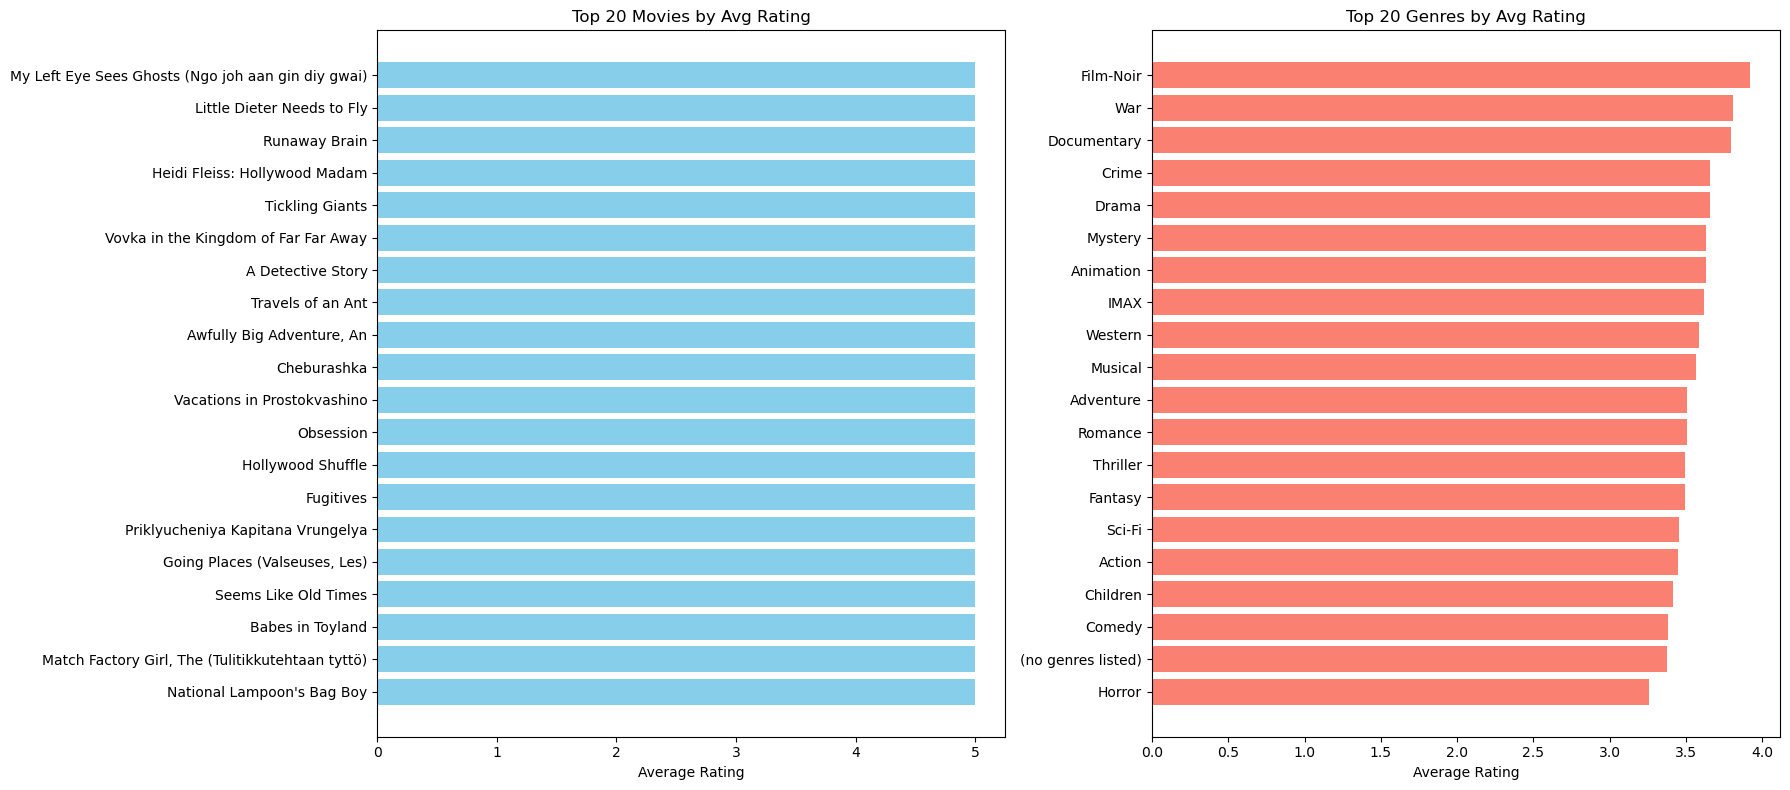

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot top movies
axes[0].barh(top_movies['title'], top_movies['avg_rating'], color='skyblue')
axes[0].set_title('Top 20 Movies by Avg Rating')
axes[0].set_xlabel('Average Rating')
axes[0].invert_yaxis()  # Highest rating at the top

# Plot top genres
axes[1].barh(top_genres['genres'], top_genres['avg_rating'], color='salmon')
axes[1].set_title('Top 20 Genres by Avg Rating')
axes[1].set_xlabel('Average Rating')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

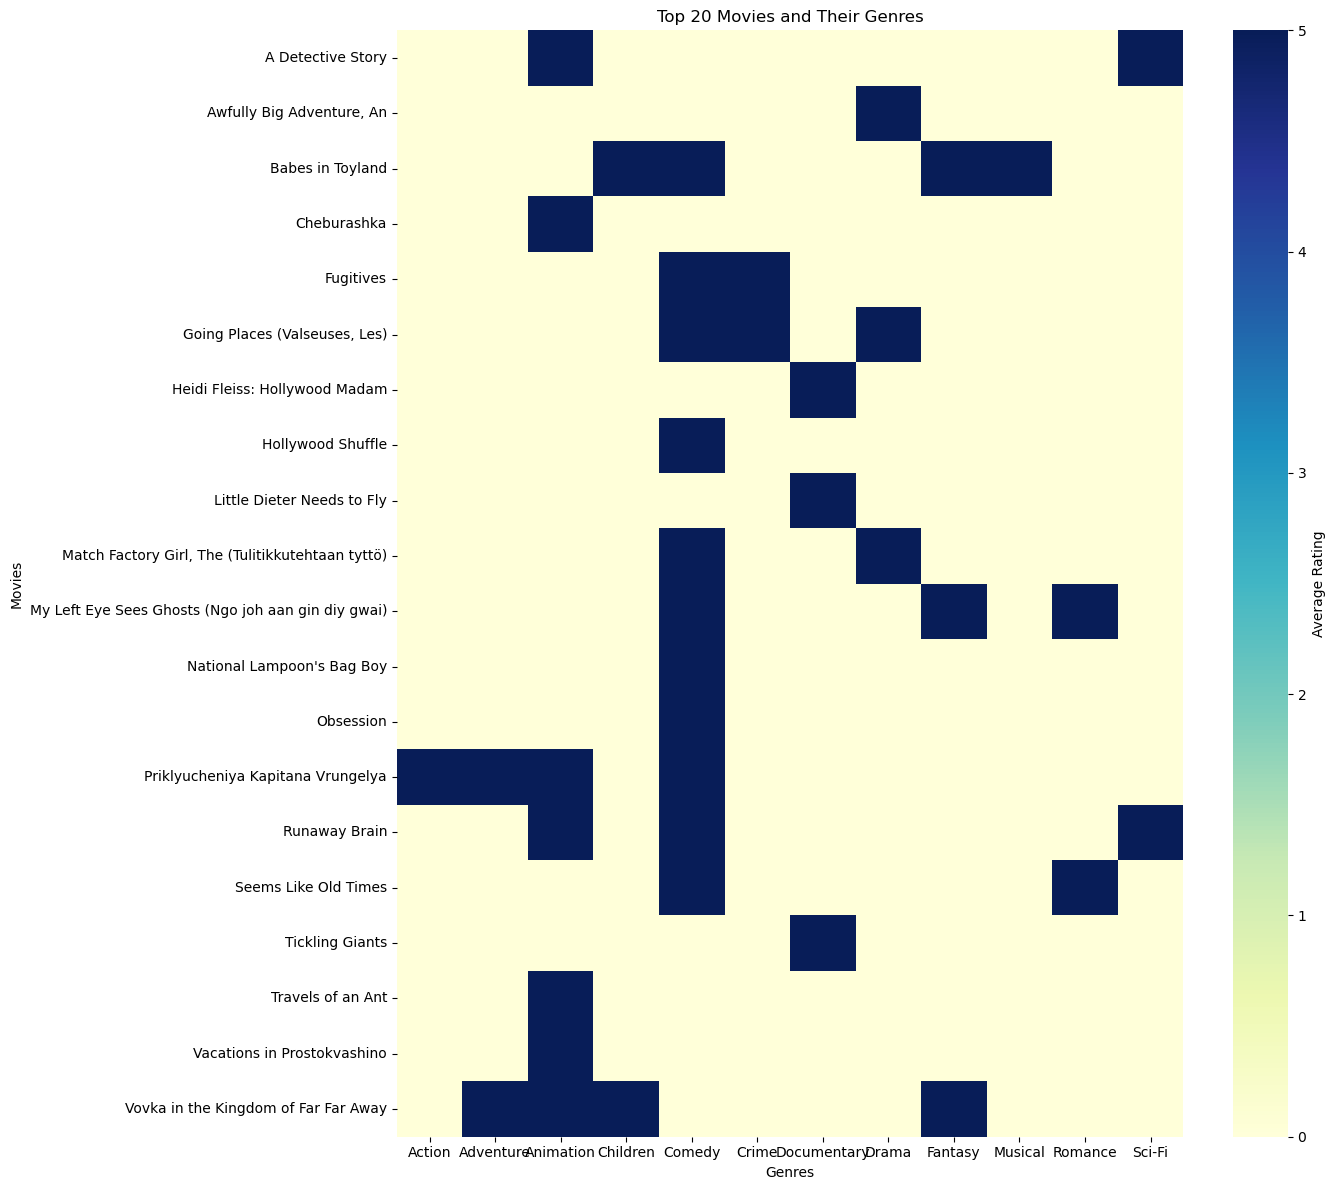

In [28]:
top_movies = (
    merged_df.groupby(['movieId', 'title', 'Year', 'genres'])['rating']
    .mean()
    .reset_index()
    .rename(columns={'rating': 'avg_rating'})
    .sort_values(by='avg_rating', ascending=False)
    .head(20)
)
top_movies['genres'] = top_movies['genres'].str.split('|')
top_movies = top_movies.explode('genres')
# Create a pivot table: movies vs genres
pivot = top_movies.pivot_table(index='title', columns='genres', values='avg_rating', fill_value=0)

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(pivot, cmap='YlGnBu', cbar_kws={'label': 'Average Rating'})
plt.title('Top 20 Movies and Their Genres')
plt.xlabel('Genres')
plt.ylabel('Movies')
plt.tight_layout()
plt.show()

In [29]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100818 entries, 0 to 100835
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   userId       100818 non-null  int64  
 1   movieId      100818 non-null  int64  
 2   rating       100818 non-null  float64
 3   timestamp    100818 non-null  int64  
 4   title        100818 non-null  object 
 5   genres       100818 non-null  object 
 6   Year         100818 non-null  object 
 7   rating_year  100818 non-null  int32  
dtypes: float64(1), int32(1), int64(3), object(3)
memory usage: 6.5+ MB


In [30]:
merged_df['Year']=merged_df['Year'].astype(int)

In [31]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100818 entries, 0 to 100835
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   userId       100818 non-null  int64  
 1   movieId      100818 non-null  int64  
 2   rating       100818 non-null  float64
 3   timestamp    100818 non-null  int64  
 4   title        100818 non-null  object 
 5   genres       100818 non-null  object 
 6   Year         100818 non-null  int64  
 7   rating_year  100818 non-null  int32  
dtypes: float64(1), int32(1), int64(4), object(2)
memory usage: 6.5+ MB


In [32]:
merged_df.describe()

,userId,movieId,rating,timestamp,Year,rating_year
count,100818.000000,100818.000000,100818.000000,1.008180e+05,100818.000000,100818.000000
mean,326.128717,19412.910552,3.501532,1.205892e+09,1994.444990,2007.721191
std,182.620110,35490.816132,1.042469,2.162414e+08,14.361424,6.889737
min,1.000000,1.000000,0.500000,8.281246e+08,1902.000000,1996.000000
25%,177.000000,1199.000000,3.000000,1.018665e+09,1990.000000,2002.000000
50%,325.000000,2991.000000,3.500000,1.186087e+09,1997.000000,2007.000000
75%,477.000000,8044.000000,4.000000,1.435994e+09,2003.000000,2015.000000
max,610.000000,193609.000000,5.000000,1.537799e+09,2018.000000,2018.000000


In [33]:
merged_df['genres'].nunique()

951

In [34]:
merged_df['title'].nunique()

9433

In [35]:
#popularity check - most watched movies
movie_stats = (
    merged_df.groupby(['movieId', 'title', 'Year'])
    .agg(avg_rating=('rating', 'mean'),
         num_ratings=('rating', 'count'))
    .reset_index()
)
# Step 3: Top 20 movies by number of ratings (most watched)
top20_by_popularity = movie_stats.sort_values(by='num_ratings', ascending=False).head(20)

print("\nTop 20 Movies by Number of Ratings:")
print(top20_by_popularity[['title', 'Year', 'num_ratings']])


Top 20 Movies by Number of Ratings:
                                                  title  Year  num_ratings
314                                        Forrest Gump  1994          329
277                           Shawshank Redemption, The  1994          317
257                                        Pulp Fiction  1994          307
510                           Silence of the Lambs, The  1991          279
1938                                        Matrix, The  1999          278
224                  Star Wars: Episode IV - A New Hope  1977          251
418                                       Jurassic Park  1993          238
97                                           Braveheart  1995          237
507                          Terminator 2: Judgment Day  1991          224
461                                    Schindler's List  1993          220
2224                                         Fight Club  1999          218
0                                             Toy Story  1995  

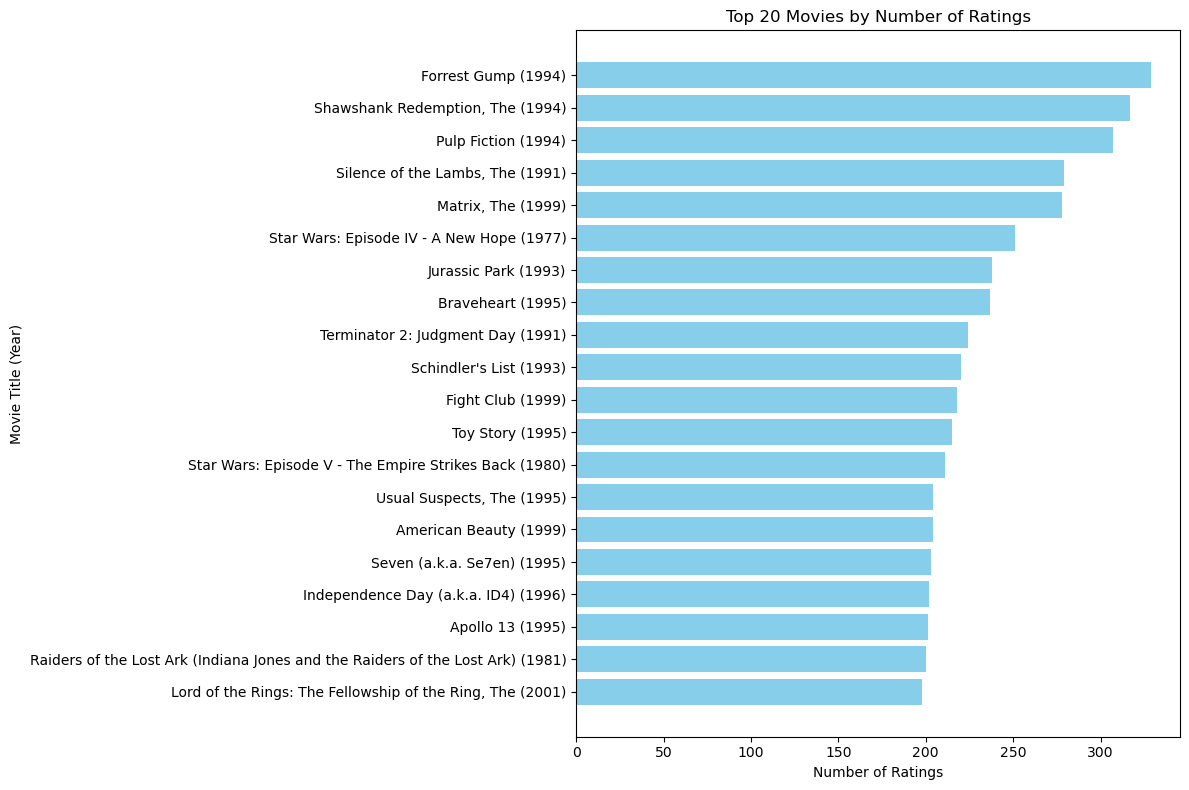

In [36]:
# Step 1: Count number of ratings per movie
movie_counts = (
    merged_df.groupby(['movieId', 'title', 'Year'])
    .size()
    .reset_index(name='num_ratings')
)

# Step 2: Select top 20 movies by number of ratings
top20_movies = movie_counts.sort_values(by='num_ratings', ascending=False).head(20)

# Step 3: Plot horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(top20_movies['title'] + " (" + top20_movies['Year'].astype(str) + ")", 
         top20_movies['num_ratings'], color='skyblue')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title (Year)')
plt.title('Top 20 Movies by Number of Ratings')
plt.gca().invert_yaxis()  # Show highest values at the top
plt.tight_layout()
plt.show()

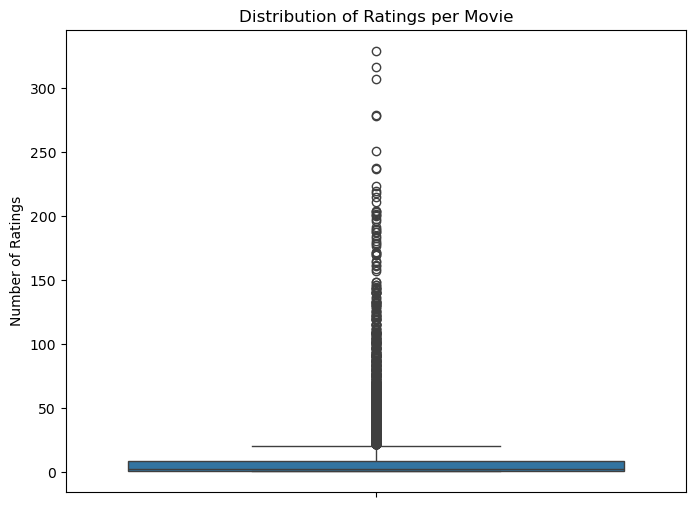

In [37]:
# Count ratings per movieId
movie_rating_counts = merged_df.groupby('movieId')['rating'].count().reset_index()
movie_rating_counts.columns = ['movieId', 'num_ratings']

# Boxplot of number of ratings per movie
plt.figure(figsize=(8, 6))
sns.boxplot(y=movie_rating_counts['num_ratings'])
plt.title("Distribution of Ratings per Movie")
plt.ylabel("Number of Ratings")
plt.show()

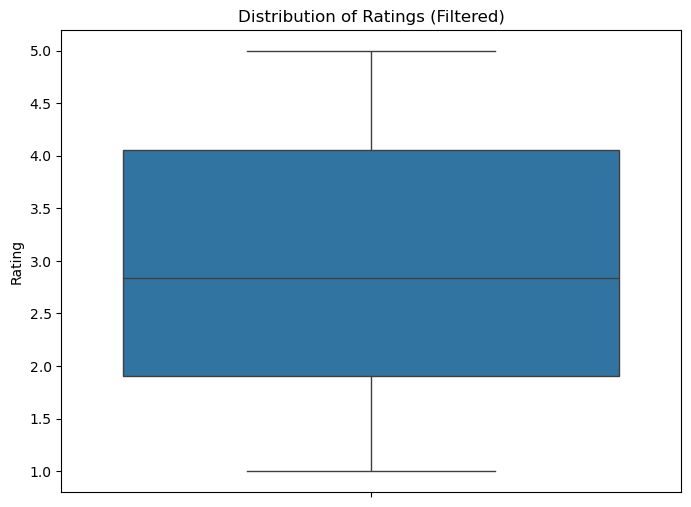

In [38]:
ratings = np.random.uniform(1, 5, size=200)  # ratings between 1 and 5
plt.figure(figsize=(8, 6))
sns.boxplot(y=ratings)
plt.ylabel("Rating")
plt.title("Distribution of Ratings (Filtered)")
plt.show()

#the mean and median are not so far so off, so this means that our data is nearly normally distributed

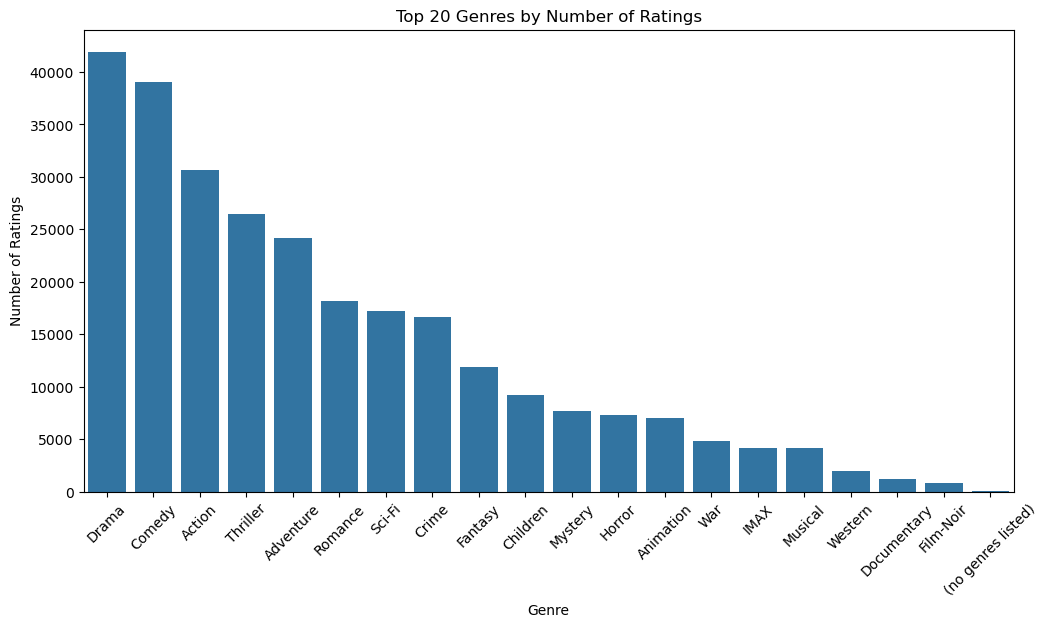

In [39]:
merged_df1 = merged_df.assign(genres=merged_df['genres'].str.split('|')).explode('genres')

# Count number of ratings per genre
ratings_per_genre = merged_df1.groupby('genres')['rating'].count().reset_index()
ratings_per_genre.rename(columns={'rating': 'num_ratings'}, inplace=True)

# Sort and select top 20 genres
top20_genres = ratings_per_genre.sort_values(by='num_ratings', ascending=False).head(20)

# Plot distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='genres', y='num_ratings', data=top20_genres)

plt.title("Top 20 Genres by Number of Ratings")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.show()


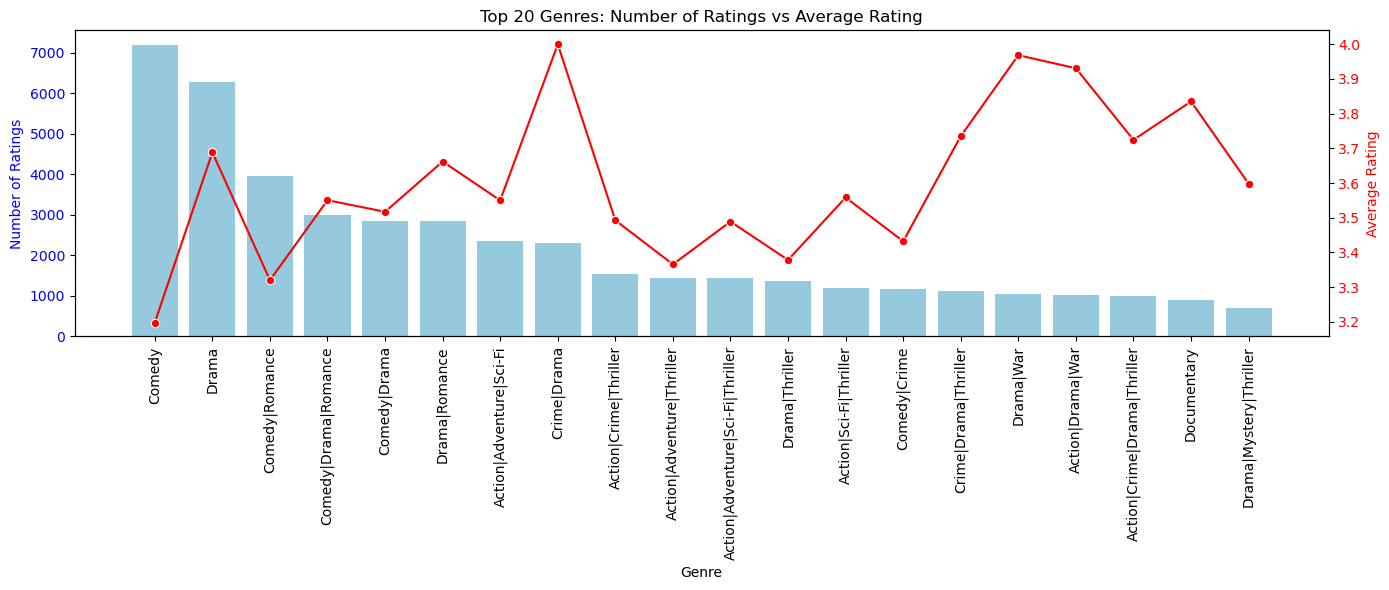

In [40]:
genres_stats = merged_df.groupby('genres').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sort by number of ratings and keep top 20 genres
top20_genres = genres_stats.sort_values(by='num_ratings', ascending=False).head(20)

# Plot combined chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar plot for number of ratings
sns.barplot(x='genres', y='num_ratings', data=top20_genres, ax=ax1, color='skyblue')
ax1.set_xlabel("Genre")
ax1.set_ylabel("Number of Ratings", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=90)

# Line plot for average rating (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(x='genres', y='avg_rating', data=top20_genres, ax=ax2, color='red', marker='o')
ax2.set_ylabel("Average Rating", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Top 20 Genres: Number of Ratings vs Average Rating")
plt.tight_layout()
plt.show()


In [41]:
# Combine features for content-based filtering
merged_df['content'] = merged_df['title'] + " " + merged_df['genres']
merged_df['content'].head(10)

0    Toy Story Adventure|Animation|Children|Comedy|...
1                      Grumpier Old Men Comedy|Romance
2                           Heat Action|Crime|Thriller
3                Seven (a.k.a. Se7en) Mystery|Thriller
4           Usual Suspects, The Crime|Mystery|Thriller
5    From Dusk Till Dawn Action|Comedy|Horror|Thriller
6         Bottle Rocket Adventure|Comedy|Crime|Romance
7                          Braveheart Action|Drama|War
8                     Rob Roy Action|Drama|Romance|War
9                            Canadian Bacon Comedy|War
Name: content, dtype: object

####  Content-based movie recommender and filtering using TF-IDF

In [42]:
merged_df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres', 'Year',
       'rating_year', 'content'],
      dtype='object')

In [43]:
# 1. Create a clean movie mapping (movieId → title + year)
movie_map = (merged_df[['movieId', 'title', 'Year']]
             .drop_duplicates()
             .set_index('movieId'))

# 2. Create the user-item matrix (users × movies)
user_item_matrix = merged_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print(f"User-item matrix shape: {user_item_matrix.shape}")

User-item matrix shape: (610, 9711)


In [44]:
# TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(merged_df['content'])
tfidf_matrix

<100818x8947 sparse matrix of type '<class 'numpy.float64'>'
	with 506443 stored elements in Compressed Sparse Row format>

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_movies(movieId, top_n=10):
    idx = merged_df[merged_df['movieId'] == movieId].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    top_indices = sim_scores.argsort()[-top_n-1:-1][::-1]
    return merged_df.iloc[top_indices][['movieId', 'title', 'genres']]

print(get_similar_movies(1))

       movieId        title                                       genres
38236        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
58570        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
89306     3114  Toy Story 2  Adventure|Animation|Children|Comedy|Fantasy
15155        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
15174     3114  Toy Story 2  Adventure|Animation|Children|Comedy|Fantasy
32052        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
65630        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
90517        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy
24148     3114  Toy Story 2  Adventure|Animation|Children|Comedy|Fantasy
53492        1    Toy Story  Adventure|Animation|Children|Comedy|Fantasy


In [46]:
# Title‑based version
indices = pd.Series(merged_df.index, index=merged_df['title']).drop_duplicates()
def recommend_content(title, top_n=5):
    """
    Recommend movies based on content similarity
    """
    if title not in indices:
        return "Movie not found"
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_similarity[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Exclude itself
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return df['title'].iloc[movie_indices]

In [47]:
# MovieId‑based version
def recommend_content(movieId, top_n=5):
    if movieId not in merged_df['movieId'].values:
        return "Movie not found"
    
    idx = merged_df[merged_df['movieId'] == movieId].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_scores = sorted(list(enumerate(sim_scores)), key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # exclude itself
    
    # Extract the actual DataFrame indices
    movie_indices = [merged_df.index[i] for i, _ in sim_scores]
    
    return merged_df.loc[movie_indices, ['movieId','title','genres']]

### Modelling

#### Model 1. Collaborative filtering using SVD

In [48]:
svd = TruncatedSVD(n_components=50, random_state=42)   # 50 latent factors works well on 100k

# Fill missing ratings with 0 
matrix_filled = user_item_matrix.fillna(0)

# Fit SVD
latent_users = svd.fit_transform(matrix_filled)      # shape: (n_users, 50)
latent_items = svd.components_                       # shape: (50, n_movies)

# Reconstruct the predicted rating matrix
predicted_ratings = np.dot(latent_users, latent_items)

# Convert back to DataFrame with same index/columns as original
predicted_df = pd.DataFrame(
    predicted_ratings,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

print("SVD model trained!")

SVD model trained!


In [49]:
from sklearn.model_selection import train_test_split

# Flatten ratings into userId, movieId, rating format
ratings = user_item_matrix.stack().reset_index()
ratings.columns = ['userId','movieId','rating']
ratings = ratings.dropna()

# Split into train/test
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 80654, Test size: 20164


In [50]:
test_preds = []
test_truth = []

for row in test.itertuples():
    user, movie, actual = row.userId, row.movieId, row.rating
    try:
        pred = predicted_df.loc[user, movie]
        test_preds.append(pred)
        test_truth.append(actual)
    except:
        continue

rmse = np.sqrt(mean_squared_error(test_truth, test_preds))
mae = mean_absolute_error(test_truth, test_preds)

print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}")


RMSE: 2.004, MAE: 1.544


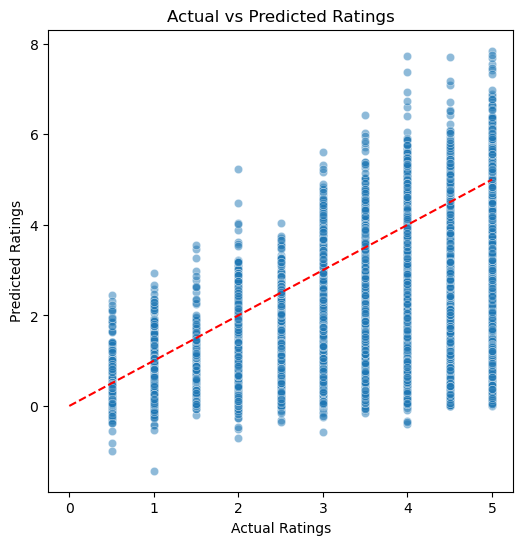

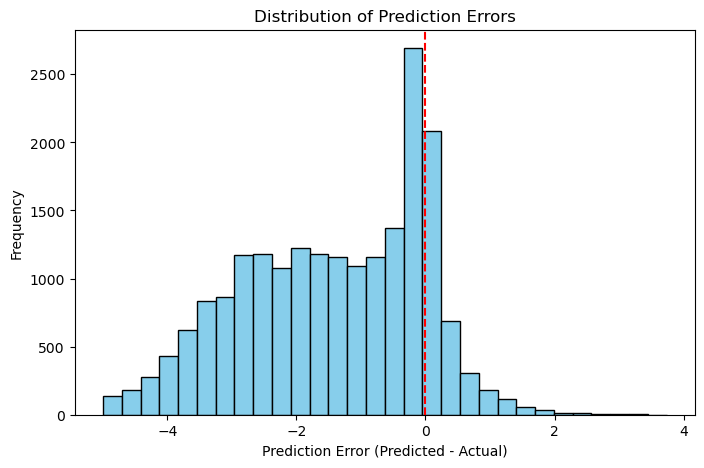

In [51]:
# Scatter plot: actual vs predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=test_truth, y=test_preds, alpha=0.5)
plt.plot([0,5],[0,5], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

# Error distribution
errors = np.array(test_preds) - np.array(test_truth)
plt.figure(figsize=(8,5))
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()


#### Recommendation function

In [52]:
def recommend_svd(user_id: int, top_n: int = 5):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found!"

    # 1. Get this user's actual ratings and predicted ratings
    actual = user_item_matrix.loc[user_id]
    pred = predicted_df.loc[user_id]

    # 2. Movies the user has NOT rated yet
    unrated_mask = actual.isna()
    unrated_movie_ids = actual[unrated_mask].index

    # 3. Get predicted scores for those movies only
    pred_unrated = pred[unrated_movie_ids]

    # 4. Get top 5
    top_ids = pred_unrated.sort_values(ascending=False).head(top_n).index

    # 5. Return nice DataFrame
    recommendations = movie_map.loc[top_ids].copy()
    recommendations['predicted_rating'] = pred_unrated[top_ids].round(2)
    recommendations = recommendations.reset_index()
    
    return recommendations[['title', 'Year', 'predicted_rating']]

#### SVD model testing using any user, here we use user 1

In [53]:
user = 1
print(f"\n Top 5 recommendations for user {user} (SVD):")
display(recommend_svd(user))


 Top 5 recommendations for user 1 (SVD):


,title,Year,predicted_rating
0,Die Hard,1988,4.17
1,"Godfather: Part II, The",1974,3.41
2,"Godfather, The",1972,3.38
3,Stand by Me,1986,2.95
4,Jaws,1975,2.92


#### Model 2. Memory based model - KNN

In [54]:
# using the transposed matrix so each row = a movie
item_matrix = user_item_matrix.T.fillna(0)   # now shape = (movies, users)

knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20)
knn.fit(item_matrix)

print("Item-based KNN model trained!")

Item-based KNN model trained!


In [55]:
def get_similar_movies_knn(movieId, top_n=5):

    idx = merged_df[merged_df['movieId'] == movieId].index[0]                        # Find the row index position for this movie
    
    movie_vector = item_matrix.iloc[idx].values.reshape(1, -1)                       # Use iloc to get the row vector
    
    distances, indices = knn.kneighbors(movie_vector, n_neighbors=top_n+1)           # Query the KNN model
    
    neighbor_indices = indices.flatten()[1:]                                         # Exclude the movie itself
    
    return merged_df.iloc[neighbor_indices][['movieId','title','genres']]


In [56]:
print(get_similar_movies_knn(1, top_n=5))  # Toy Story

      movieId                          title                            genres
2353      407        In the Mouth of Madness                   Horror|Thriller
418      1923   There's Something About Mary                    Comedy|Romance
615       141                  Birdcage, The                            Comedy
224      3703  Road Warrior, The (Mad Max 2)  Action|Adventure|Sci-Fi|Thriller
314       222              Circle of Friends                     Drama|Romance


In [57]:
def recommend_knn(user_id: int, top_n: int = 5):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found!"

    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings.dropna().index.tolist()
    
    if not rated_movies:
        return "User has no ratings yet!"

    # We'll collect candidate scores
    candidate_scores = pd.Series(dtype=float)

    # For every movie the user rated highly, find similar movies
    for movie_id in rated_movies:
        rating = user_ratings[movie_id]
        if rating < 3.5:          # only consider movies user liked
            continue
            
        # Find similar movies
        movie_idx = item_matrix.index.get_loc(movie_id)
        distances, indices = knn.kneighbors(
            item_matrix.iloc[movie_idx].values.reshape(1, -1),
            n_neighbors=15
        )
        
        similar_movie_ids = item_matrix.index[indices.flatten()[1:]]  # exclude self
        similarity_scores = 1 - distances.flatten()[1:]               # convert distance to similarity
        
        # Weight by how much user liked the original movie
        weighted_scores = pd.Series(similarity_scores * rating, index=similar_movie_ids)
        candidate_scores = candidate_scores.add(weighted_scores, fill_value=0)

    # Remove movies user already rated
    candidate_scores = candidate_scores.drop(rated_movies, errors='ignore')
    
    # Get top 5
    top_ids = candidate_scores.sort_values(ascending=False).head(top_n).index
    
    recommendations = movie_map.loc[top_ids].copy()
    recommendations['score'] = candidate_scores[top_ids].round(2)
    recommendations = recommendations.reset_index()
    
    return recommendations[['title', 'Year', 'score']]


#### Testing the - user‑centric model i.e personalized recommendation list for a user

In [58]:
print(f"\nTop 5 recommendations for user {user} (Item-based KNN):")
display(recommend_knn(user))


Top 5 recommendations for user 1 (Item-based KNN):


,title,Year,score
0,Ferris Bueller's Day Off,1986,58.02
1,Terminator 2: Judgment Day,1991,36.39
2,Aliens,1986,35.83
3,"Godfather, The",1972,33.69
4,Die Hard,1988,31.40


- These movies are recommended specifically for user 1, based on what they rated highly.
- The list will change for different users depending on their rating history
- Higher scores mean the movie is more similar to the ones the user liked, weighted by how much they liked them.
- Example: Ferris Bueller’s Day Off has a much higher score (58.02) than Die Hard (31.40), so it’s considered a stronger recommendation.


#### Interpretation
- Unlike latent factor models (SVD), item‑based KNN recommendations are easy to explain:
“We recommended Die Hard because you liked similar action movies.”
- The output tells you which movies are most similar to the ones the user liked, how strong each recommendation is, and what patterns the system is capturing in the user’s taste.


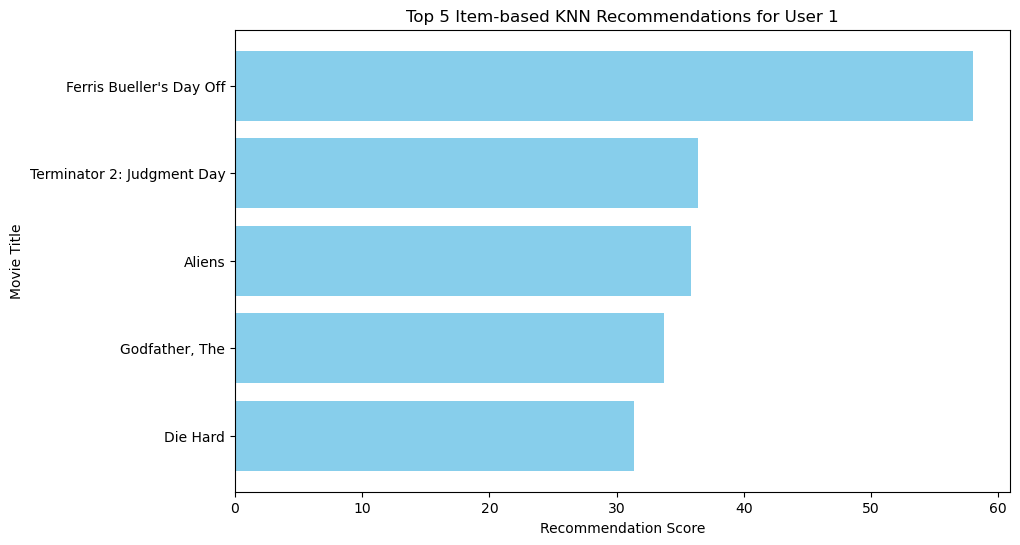

In [59]:
recommendations = {
    "Ferris Bueller's Day Off": 58.02,
    "Terminator 2: Judgment Day": 36.39,
    "Aliens": 35.83,
    "Godfather, The": 33.69,
    "Die Hard": 31.40
}

# Plot bar chart
plt.figure(figsize=(10,6))
plt.barh(list(recommendations.keys()), list(recommendations.values()), color='skyblue')
plt.xlabel("Recommendation Score")
plt.ylabel("Movie Title")
plt.title("Top 5 Item-based KNN Recommendations for User 1")
plt.gca().invert_yaxis()  # highest score at the top
plt.show()
